# Animations — Setting the Sky in Motion

A sky plot freezes a view at a single instant — but astronomy also has a time axis. Galaxies
rotate through a cube's channels, stars drift out of their constellations (on astronomical time scales), the
day/night terminator crawls across a planet, an array's shared sky slides west with the
clock. This notebook is about turning those into **movies**: every animation
here is a matplotlib figure plus an update function, rendered to a file you
can put in a talk, a README, or these very docs.

**Contents**

1. [How an animation is built](#1.-How-an-animation-is-built)
2. [Animating data on a fixed frame](#2.-Animating-data-on-a-fixed-frame)
3. [The sky in motion](#3.-The-sky-in-motion)
4. [Rotating planets](#4.-Rotating-planets)
5. [Day and night in motion](#5.-Day-and-night-in-motion)
6. [The Sun across the year](#6.-The-Sun-across-the-year)
7. [Co-visibility over a sidereal day](#7.-Co-visibility-over-a-sidereal-day)
8. [Putting it together](#8.-Putting-it-together)
9. [Where to next](#9.-Where-to-next)

**Overview.** §1 lays out the whole recipe — a figure, an update function, a
writer — and the two update patterns everything else uses: *artist updates*
on a fixed frame (fast: a cube's channels in §2, proper motions in §3, the
Sun and a VLBI network's sky in §6–§7) and *WCS updates* that move the view
itself (the rotating globes of §4–§5). The capstone (§8) stacks the layers
into a day of Earth: spin, exaggerated nutation, a crawling terminator, and
city lights against a starfield. One presentation note up front: a movie's
colors are baked into its file — it can't restyle itself when the page theme
flips — so every animation here is saved with a *transparent* background and
floats directly on the page, reading equally well in light and dark docs
(§1 shows how). And every movie ships with a full-resolution **filmstrip**
of key frames — the print-safe fallback §1 argues for.

> **A note on the data.** The planet textures and Earth rasters (NASA Blue
> Marble / Black Marble and friends) are large files that ship outside the
> pip package, so they live in the repository's `examples/data/` directory —
> its README lists where each file comes from. The movies on this page are
> pre-rendered, so nothing needs downloading to read along; with the files
> in place, the code runs exactly as shown. The HI cube, the Hipparcos
> proper-motion catalog, and everything else used here is bundled.

In [1]:
import os

import warnings

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.wcs import FITSFixedWarning
from matplotlib.animation import FuncAnimation
from PIL import Image

import skyplothelper as sph

sph.set_style(base="structural")

DATA = "../../examples/data"
ANIM = "../_static/animations"        # committed GIFs live with the docs assets
os.makedirs(ANIM, exist_ok=True)

# Data series colors — the `uranometria` cycle palette reads well on light and
# dark pages alike, which matters here: a saved movie's colors are baked in.
C = sph.CYCLE_PALETTES["uranometria"]["colors"]

# These movies save with a *transparent* exterior so each frame floats on the
# page rather than sitting in a box — see §1. Two constants make that read on
# both light and dark docs: a deep-navy canvas that contrasts with either page,
# and a dark text stroke so light labels stay legible on a light page too (a
# light glyph with a dark outline works either way). One rule keeps the GIFs
# small: keep moving artists *on* the opaque canvas — a WCS frame clips your
# data to its own outline, so a sweeping ring or drifting region never spills
# onto the see-through border; only free-floating text needs placing with care.
SKY = "#16203A"                                     # opaque "night" canvas for sky frames
GLOW = [pe.withStroke(linewidth=2.6, foreground="#0E1117")]   # dark stroke for light text


# WebP is this notebook's animation format: smaller than GIF, with 8-bit
# (smooth) transparency instead of GIF's 1-bit, and rendered natively by GitHub
# and Sphinx. `sph.save_animation` owns the heavy lifting — writer choice, the
# see-through exterior, the WebP encode; the wrapper below adds only this
# notebook's conventions (a crispness bump and a size report).
SIZE_BUMP = 1.18               # ~18% larger canvas for crisper rendering; dial back per clip if a file runs heavy
OUTPUT_FORMAT = "webp"         # docs default; set "gif"/"mp4" to regenerate the legacy archive instead
LEGACY_DIR = "legacy_animations"  # local dir for regenerated pre-webp gif/mp4 originals


def save_anim(ani, fig, slug, fps=10, dpi=80, lossless=False, bg="transparent",
              bump=True, fmt=None):
    """Save an animation next to the docs as WebP and report its size.

    A thin wrapper over ``sph.save_animation`` (which owns writer choice, the
    see-through exterior, and the WebP encode) that adds only our conventions: a
    ~18% crispness bump (``SIZE_BUMP``) and the size ``print``. WebP is **lossy**
    by default — smaller than the GIF for photographic scenes (globes, colormaps,
    filled regions) and comparable for line art, with 8-bit transparency
    throughout. Pass ``lossless=True`` only for a *very sparse* scene — a few thin
    lines or points on a mostly-empty transparent frame (a lone orbit, the S-star
    ellipses) — where it can edge out lossy; the size ``print`` tells you if it
    helped. (Re-emitted full-color frames don't lossless-compress like a 256-color
    GIF, so lossless is a narrow win, not the rule.) ``bg="transparent"`` floats
    the frame; ``bg="<color>"`` renders a solid card. To regenerate a legacy
    format, set ``OUTPUT_FORMAT`` (or pass ``fmt=``) to "gif"/"mp4" — it writes
    into the gitignored ``LEGACY_DIR``; the committed docs asset is always the
    ``.webp``.
    """
    fmt = fmt or OUTPUT_FORMAT
    eff_dpi = round(dpi * SIZE_BUMP) if bump else dpi
    outdir = ANIM if fmt == "webp" else LEGACY_DIR
    os.makedirs(outdir, exist_ok=True)
    path = f"{outdir}/animations__{slug}.{fmt}"
    sph.save_animation(ani, fig, path, bgcolor=bg, quality=66, fps=fps,
                       dpi=eff_dpi, lossless=(lossless and fmt == "webp"))
    plt.close(fig)
    print(f"{os.path.basename(path)}: {os.path.getsize(path)/1e6:.2f} MB")


LOGO = "../_static/logo/logo_6_wordmark-dark_mark.png"   # the `_mark` files are the
_LOGO = np.asarray(Image.open(LOGO).convert("RGBA"), float) / 255.0   # backing-plate-free ones


def add_logo(fig, left, bottom, width=0.30, alpha=0.55):
    """Stamp the wordmark on a movie worth downloading, so it travels with credit.

    Two rules come out of the artwork: it is **white**, so it only reads over the
    *opaque* canvas — on a see-through margin it would vanish against a light
    page — and the `_mark` file is the one without a solid backing plate.
    ``left``/``bottom``/``width`` are figure fractions; the height follows from
    the artwork's own aspect so it is never stretched.
    """
    art = _LOGO.copy()
    art[..., 3] *= alpha                       # fade the artwork, not a gray box
    fig_w, fig_h = fig.get_size_inches()
    aspect = _LOGO.shape[1] / _LOGO.shape[0]
    lax = fig.add_axes((left, bottom, width, width * (fig_w / fig_h) / aspect))
    lax.imshow(art, interpolation="antialiased")
    lax.axis("off")
    lax.patch.set_alpha(0)
    return lax

Seeing is believing, so before any of the mechanics — Mars, one full
rotation, in a dozen lines:

In [2]:
# fig-slug: mars-spin
from skyplothelper.globe.animation import animate_globe  # noqa: E402, I001  (§4 explains this import)

mars_hdu = sph.pseudofits_from_image(f"{DATA}/planet_maps/2k_mars.jpg", geo=True)
spin = sph.make_globe_angles([0, sph.obliquities["mars"], 0], 36, spin_rate=10)

animate_globe(*spin, bgim=mars_hdu,
              show_ticklabels=False,
              savepath=f"{ANIM}/animations__mars-spin.webp", bgcolor="transparent",
              webp_lossless=False,                       # photographic surface -> lossy webp
              frame_kwargs={"direction": "geographic", "Naxispix": 360,
                            "tick_style": "native",
                            "gridcolor": "#3B2418", "gridalpha": 0.5},
              dpi=round(80 * SIZE_BUMP), figsize=(4.8, 4.8))   # SIZE_BUMP: crisper canvas

![Mars making one full rotation at its true axial tilt](../_static/animations/animations__mars-spin.webp)

Thirty-six frames, one writer, one WebP — Valles Marineris sweeping past at
Mars's true 25-degree tilt. Everything in that call will be unpacked over the
next sections; first, how the pieces fit.

## 1. How an animation is built

Every animation in this notebook is the same three-step recipe:

1. **Build a figure** — any skyplothelper frame, decorated however you like.
2. **Write an update function** — change *something* per frame: an artist's
   data, an image's array, or the frame's WCS itself.
3. **Hand both to a writer** — `matplotlib.animation.FuncAnimation` calls your
   update once per frame and a writer stacks the results into a movie file.

The interesting choice is in step 2. There are two update patterns, and the
difference is the cost per frame:

- **Artist update (fast).** The frame — projection, gridlines, tick labels —
  never changes; only the *data on it* moves. (An *artist* is matplotlib's
  word for anything drawn: a line, an image, a text label.) Update in place
  with `line.set_data(...)`, `image.set_array(...)`, `text.set_text(...)`.
  Tens of milliseconds per frame; this covers most science animations (a
  cube's channels, catalog positions over time, a sweeping overlay).
- **WCS update (slower).** The *view itself* changes — a globe rotates, the
  projection center drifts. The frame's WCS is mutated per frame and any
  draped imagery is re-reprojected onto the new view. This is what the globe
  animators in §4–§5 do; expect a second or so per frame.

(If you've met matplotlib's `blit=True` speedup: it only accelerates *live*
playback in a window — writing a file redraws every frame regardless, so
none of the examples here bother with it.)

Here is the whole recipe at its smallest: one dot riding a great circle
around an all-sky frame, with a trail growing behind it. Two moves to
note: `transform=ax.get_transform("world")` — so `set_data` takes sky
coordinates, exactly like a static plot — and the NaN split, which breaks the
trail where the path wraps off one edge of the map and back onto the other:

In [3]:
def wrap_split(lons, lats, center=180):
    """Wrap longitudes to the frame's range and NaN-split jumps across the edge."""
    lons = (np.asarray(lons, float) - (center - 180)) % 360 + (center - 180)
    lats = np.asarray(lats, float)
    cut = np.where(np.abs(np.diff(lons)) > 180)[0] + 1
    return np.insert(lons, cut, np.nan), np.insert(lats, cut, np.nan)


# A full great circle, tilted 30 deg to the equator: every point 90 deg from a
# pole placed at lat +60. (`small_circle` with radius 90 IS a great circle.)
path_lon, path_lat = sph.small_circle(0, 60, 90, n_pts=144)

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(7.2, 4.05))
    ax = sph.make_wcs_frame(111, projection="AIT", center=180, fig=fig)
    ax.set_facecolor(SKY)              # opaque sky; the figure exterior is transparent
    sph.format_ticklabels(ax, fontsize=8, color="0.9",
                          stroke_color="#0E1117", stroke_lw=2.4)
    trail, = ax.plot([], [], color=C[0], lw=1.6, alpha=0.85,
                     transform=ax.get_transform("world"))
    dot, = ax.plot([], [], "o", color="gold", ms=9, mec="none",
                   transform=ax.get_transform("world"), zorder=5)

    def update(i):
        trail.set_data(*wrap_split(path_lon[:i + 1], path_lat[:i + 1]))
        dot.set_data([path_lon[i]], [path_lat[i]])

    ani = FuncAnimation(fig, update, frames=len(path_lon), interval=50)
    save_anim(ani, fig, "first-orbit", fps=20, dpi=70, lossless=True)  # one dot + line -> lossless wins

animations__first-orbit.webp: 0.24 MB


![A dot riding a great circle around an all-sky frame](../_static/animations/animations__first-orbit.webp)

That is the entire mechanism — everything below is this loop with better
scenery. Three practical matters before the scenery, though: **how fast it
plays**, **where the movie goes**, and **how big it is**.

First the speed, because two knobs look like they control it and only one
does: `interval=` (milliseconds between frames) matters only for *live*
playback in a notebook window; the speed of a saved *file* is set entirely
by the `fps=` you pass at save time. When the two disagree, the file
believes `fps`.

| Output | Writer | Traits | Reach for it when |
|--------|--------|--------|-------------------|
| `.webp` | `WebPWriter` | small *and* 8-bit transparent, loops, native in modern browsers/GitHub/Sphinx | **docs & READMEs — the default here** |
| `.gif` | `pillow` | universal, loops, no installs; larger files, 1-bit (jagged) transparency | a fallback for very old viewers |
| `.mp4` | `ffmpeg` | smallest for *opaque* photographic clips; needs ffmpeg; no transparency | talks, paper supplements |
| inline player | `to_jshtml()` | scrubber + step buttons inside the notebook | live sessions, frame-by-frame inspection |
| filmstrip | — | a static row of key frames | print, PDF, anywhere a movie can't play |

Every animation here is saved through the `save_anim` helper above, which wraps
`sph.save_animation` — one call that picks the writer from the file extension,
handles the see-through background, and encodes the movie. **WebP is why this
notebook no longer has to choose between transparency and file size** the way
GIF-versus-MP4 once forced: it floats on a transparent page, stays small, and
renders natively wherever the docs go. The one knob worth understanding is
**lossy vs lossless**, and it follows from the content:

- **Most scenes** — photographic globes, colormap movies, *and* busy line art
  (drifting regions, dense star trails) → **lossy** WebP (the default): 30–50%
  of the GIF for photographic, roughly GIF-sized for line art.
- **Very sparse** scenes — a few thin lines or points on a mostly-empty frame
  (a lone orbit, the S-star ellipses) → **lossless** (`lossless=True`) can edge
  out lossy. It's content-dependent, so let the size `print` decide: re-emitted
  full-color frames don't compress like a 256-color GIF, so lossless is a narrow
  win, not a blanket rule for anything "sparse".

For a talk or a paper supplement, the same `sph.save_animation` call with an
`.mp4` path gives you H.264 — the smallest option for an *opaque* photographic
clip, at the cost of transparency (ffmpeg on your PATH does the encoding):

```python
sph.save_animation(ani, fig, "orbit.mp4", bgcolor="#0E1117", fps=20, dpi=150)
# codec flags pass straight through:
sph.save_animation(ani, fig, "orbit.mp4", bgcolor="#0E1117", fps=20, dpi=150,
                   extra_writer_args=["-vcodec", "libx265", "-crf", "28"])
# (the globe animators of §4–§5 take the same list via extra_writer_args=)
```

> **Note:** keep committed animations small: render the *movie* at modest pixel
> dimensions (the `dpi=` passed to `save`, nudged up ~18% here by `SIZE_BUMP`
> now that WebP buys the room for a crisper frame), and pair it with a
> **filmstrip** of key frames at full resolution — motion reads fine small,
> detail lives in the still. Every section below follows that pattern, and the
> file-size `print` in `save_anim` is there on purpose: watch it. Frame count
> is the other half of the budget — size and render time both scale linearly
> with it. As a rule of thumb, 30–50 frames at 8–20 fps covers most loops:
> spend frames on fast motion, save them on slow.

**A floating frame.** Nearly every movie here saves with a see-through exterior
(`bgcolor="transparent"`), so the sky ellipse or planet disk floats on the page
instead of sitting in a box — the same file then reads on light *and* dark
docs. (The exceptions are the two whose decorations sweep *past* the disk —
§4's pole rods and §8's starfield capstone — which sit on a solid card
instead.) WebP's **8-bit alpha** keeps those floating edges smoothly
anti-aliased on either page, where a GIF's 1-bit cutout would stair-step them.
Two habits keep it clean, both baked into the frames below: light text carries
a dark **stroke** so it stays legible over a light page, and moving artists are
kept *on* the opaque canvas — a WCS frame clips your data to its own outline,
so a sweeping ring or region never reaches the transparent border; you only
have to place a *drifting text label* (a date, a year counter) on the canvas
rather than out in the margin.

In a live notebook you can skip files entirely and scrub the animation
in-place:

```python
from IPython.display import HTML
HTML(ani.to_jshtml())          # play/pause/step controls, no file written
```

(We save WebP files here so the rendered docs stay self-contained.)

And the filmstrip fallback — the same update function, called at a few chosen
frames on a row of static axes:

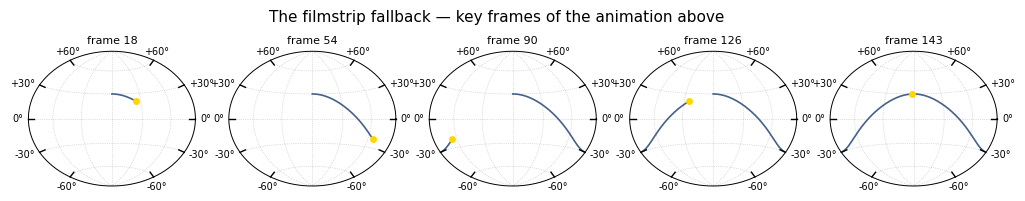

In [4]:
# fig-slug: first-orbit-filmstrip
# Panel boxes sized 2:1 so each AIT frame reads as a proper ellipse, not a circle.
fig = plt.figure(figsize=(12.5, 1.75))
picks = [18, 54, 90, 126, 143]
for k, i in enumerate(picks):
    ax = sph.make_wcs_frame(151 + k, projection="AIT", center=180, fig=fig)
    ax.plot(*wrap_split(path_lon[:i + 1], path_lat[:i + 1]), color=C[0], lw=1.2,
            transform=ax.get_transform("world"))
    ax.plot([path_lon[i]], [path_lat[i]], "o", color="gold", ms=5, mec="none",
            transform=ax.get_transform("world"))
    ax.set_title(f"frame {i}", fontsize=8)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
fig.suptitle("The filmstrip fallback — key frames of the animation above", y=1.12, fontsize=11)
plt.show()

## 2. Animating data on a fixed frame

The fast pattern first: the frame stays put, the data moves. The classic
astronomy case is a **spectral cube** — a stack of sky images, one per
velocity channel. Watching the channels play as a movie is often the fastest
way to *see* a galaxy rotate: emission sweeps from one side of the disk to
the other as the velocity advances.

The bundled cube is VLA HI imaging of the dwarf galaxy **DDO 70 (Sextans B)**
— 43 channels of 21-cm emission. One `imshow` + one `set_array` per frame,
shown in the bundled `sph.dusk` colormap (the **Styling** tutorial tours the
full `sph.*` set). And because the stretch is fixed, the colorbar comes for
free: drawn once, up front, it stays truthful for every frame of the movie:

In [5]:
# (The cube's 1997-era header carries harmless WCS quirks astropy likes to
# normalize; silence only that specific warning so the outputs stay clean.)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FITSFixedWarning)
    with fits.open(f"{DATA}/ddo70_hi_subcube.fits") as hdul:
        cube = np.squeeze(hdul[0].data).astype(float)  # (43, 225, 225)
        chdr = hdul[0].header
    cwcs = WCS(chdr).celestial
# Velocity axis, from the header's linear axis-3 description (km/s):
vels = chdr["CRVAL3"] + (np.arange(cube.shape[0]) + 1 - chdr["CRPIX3"]) * chdr["CDELT3"]

# One fixed stretch for every channel — the flicker of a per-frame stretch is
# exactly what you don't want in a channel movie.
vmin, vmax = 0.0, np.nanpercentile(cube, 99.8)

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(6.1, 5.2))
    ax = fig.add_subplot(111, projection=cwcs)
    # Animations save without bbox_inches="tight" — set the margins by hand so
    # the axis labels aren't clipped in the movie.
    fig.subplots_adjust(left=0.155, right=0.84, top=0.91, bottom=0.11)
    im = ax.imshow(cube[0], vmin=vmin, vmax=vmax, cmap="sph.dusk")
    # The canvas is the image itself (opaque); only the labels sit on the
    # transparent margin, so they get the dark stroke to read on a light page.
    sph.format_ticklabels(ax, fontsize=8, color="0.9",
                          stroke_color="#0E1117", stroke_lw=2.4)
    cb = sph.add_colorbar(im, ax, label="Jy/beam", mode="divider",
                          stroke_color="#0E1117", stroke_lw=2.4)
    cb.ax.tick_params(labelsize=8)
    label = ax.text(0.03, 0.965, "", transform=ax.transAxes, va="top",
                    fontsize=10, color="0.95", family="monospace", path_effects=GLOW)
    ax.set_title("DDO 70 — HI channel maps", fontsize=11, color="0.95",
                 path_effects=GLOW)

    def update(i):
        im.set_array(cube[i])
        label.set_text(f"v = {vels[i]:6.1f} km/s   ch {i + 1:2d}/{len(cube)}")

    ani = FuncAnimation(fig, update, frames=len(cube), interval=120)
    save_anim(ani, fig, "cube-channels", fps=8, dpi=80)

animations__cube-channels.webp: 0.40 MB


![DDO 70 HI channel maps playing as a movie](../_static/animations/animations__cube-channels.webp)

The rotation is unmistakable in motion: emission enters at one velocity edge
on the galaxy's approaching side and exits on the receding side. The
filmstrip version summarizes the same sweep for print:

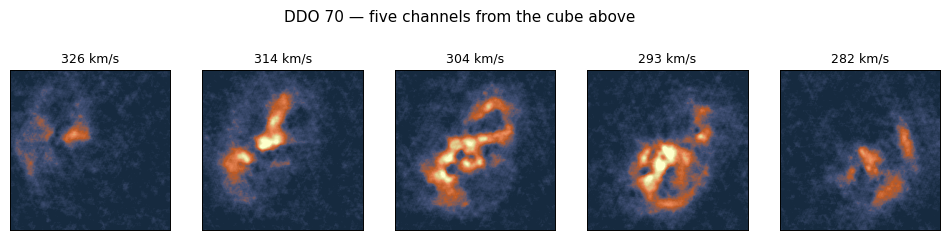

In [6]:
# fig-slug: cube-filmstrip
fig = plt.figure(figsize=(12, 2.9))
picks = [4, 13, 21, 29, 38]
for k, i in enumerate(picks):
    ax = fig.add_subplot(1, 5, k + 1, projection=cwcs)
    ax.imshow(cube[i], vmin=vmin, vmax=vmax, cmap="sph.dusk")
    ax.set_title(f"{vels[i]:.0f} km/s", fontsize=9)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
        c.set_axislabel("")
fig.suptitle("DDO 70 — five channels from the cube above", fontsize=11)
plt.show()

### The blink comparator

The oldest animation in astronomy predates the computer: Clyde Tombaugh found
Pluto in 1930 by *blinking* two photographic plates taken six nights apart —
flip between them fast enough and the one dot that moved leaps out of ten
thousand that didn't. It's still one of the best ways to show a moving object, and as
an animation it is trivial: **two frames**. (The plates below are simulated —
a random star field with one planted wanderer — but the wanderer's hop
matches Pluto's real retrograde drift over those six nights.)

In [7]:
rng = np.random.default_rng(1930)
n_star = 130
sra = 110.0 + (rng.random(n_star) - 0.5) * 1.15    # a ~1 deg field near delta Gem
sdec = 22.0 + (rng.random(n_star) - 0.5) * 1.15
smag = 2.5 + 4.0 * rng.random(n_star)

# The one that moves: retrograde drift of ~7 arcmin over the six nights.
pluto = np.array([[110.052, 21.968], [109.938, 21.987]])
epochs = ["1930 Jan 23", "1930 Jan 29"]

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(5.2, 5.2))
    ax = sph.make_wcs_frame(111, projection="TAN", center=(110.0, 22.0),
                            fov_deg=1.15, fig=fig, grid=False)
    ax.set_facecolor(SKY)              # the "plate"; figure exterior is transparent
    # A photographic plate has no coordinate labels — hide them for the look.
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
        c.set_axislabel("")
    ax.scatter(sra, sdec, s=(6.5 - smag) ** 2.6, color="w", lw=0,
               transform=ax.get_transform("world"))
    moving, = ax.plot([], [], "o", color="w", ms=4.5, mec="none",
                      transform=ax.get_transform("world"))
    tag = ax.text(0.04, 0.955, "", transform=ax.transAxes, va="top",
                  fontsize=10, color="0.9", family="monospace", path_effects=GLOW)
    ax.set_title("Blink comparison — one of these dots moves", fontsize=11,
                 color="0.95", path_effects=GLOW)

    def update(i):
        moving.set_data([pluto[i, 0]], [pluto[i, 1]])
        tag.set_text(f"plate {i + 1} · {epochs[i]}")

    ani = FuncAnimation(fig, update, frames=2, interval=600)
    save_anim(ani, fig, "blink-comparator", fps=1.6, dpi=80, lossless=True)

animations__blink-comparator.webp: 0.01 MB


![Two-plate blink comparison](../_static/animations/animations__blink-comparator.webp)

The pacing knob here is just the frame rate (`fps=1.6` — a little over half a
second per plate, about what the mechanical comparators used). Two frames,
one moving artist: the whole discovery technique in a dozen lines. (Found
it? It starts just left of dead center, a hair below the midline, and hops
to the right — westward, mid-retrograde — between the plates.)

## 3. The sky in motion

The "fixed stars" aren't. Every star in the **Vector Fields** tutorial's
proper-motion maps is drifting by tens of milliarcseconds a year — invisible
in a human lifetime, dramatic over a hundred thousand. An animation turns
those static arrows into what they actually describe: *motion*.

The bundled `hipparcos_bright_pm.csv` carries proper motions for every
naked-eye star, so we can watch the most familiar asterism in the northern
sky — the Big Dipper — come apart. Linear propagation is one line of arithmetic
per axis: `pmRA` is $\mu_{\alpha^*}$ (milliarcsec/yr, already including the
$\cos\delta$ compression), so the RA drift is `pmRA / cos(dec)`, and Dec
drifts by `pmDE` directly.

> **Where the CSV came from.** It's a plain subset of the Hipparcos catalog,
> every star brighter than $V = 6$. `sph.search_vizier` does *cone* searches;
> for an all-sky cut like this you go one level down to `astroquery` — the
> **Catalog Queries** tutorial shows the full pattern, but the whole recipe is:
>
> ```python
> from astroquery.vizier import Vizier
> v = Vizier(columns=["HIP", "RAICRS", "DEICRS", "Vmag", "Plx", "pmRA", "pmDE"],
>            column_filters={"Vmag": "<6.0"}, row_limit=-1)
> hip = v.get_catalogs("I/239/hip_main")[0].to_pandas()   # the Hipparcos main catalog
> ```
>
> Save that to CSV once and every animation below reads from disk — no live
> query on each run.

In [8]:
import pandas as pd  # noqa: E402  (imported where the catalog work begins)

hip = pd.read_csv(f"{DATA}/hipparcos_bright_pm.csv").set_index("HIP")
uma = hip[(hip.RAICRS > 150) & (hip.RAICRS < 220)
          & (hip.DEICRS > 40) & (hip.DEICRS < 70)]

# The seven Dipper stars, in stick-figure order: handle tip -> bowl, closing
# the bowl back at Megrez.   (Alkaid, Mizar, Alioth, Megrez, Phecda, Merak, Dubhe)
DIPPER = [67301, 65378, 62956, 59774, 58001, 53910, 54061, 59774]


def propagate(df, t_yr):
    """Positions after t_yr years of linear proper motion (deg)."""
    ra = df.RAICRS + t_yr * df.pmRA / 3.6e6 / np.cos(np.radians(df.DEICRS))
    dec = df.DEICRS + t_yr * df.pmDE / 3.6e6
    return ra.to_numpy(), dec.to_numpy()


times = np.linspace(-100_000, 100_000, 81)          # 2,500-yr steps
sizes = (6.7 - uma.Vmag.to_numpy()) ** 2.4

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(5.8, 5.4))
    ax = sph.make_wcs_frame(111, projection="ZEA", center=(186, 55.5),
                            fov_deg=40, fig=fig)
    ax.set_facecolor(SKY)              # opaque sky; figure exterior is transparent
    fig.subplots_adjust(left=0.15, right=0.96, top=0.92, bottom=0.1)
    # format_ticklabels strokes the RA/Dec titles too, so the light auto labels on
    # the transparent margin stay legible on a light page (even on this ZEA disk).
    sph.format_ticklabels(ax, fontsize=8, color="0.9",
                          stroke_color="#0E1117", stroke_lw=2.4, axis_labels=True)
    tr = ax.get_transform("world")

    # Today's Dipper as a fixed ghost — the yardstick the distortion is read against.
    g_ra, g_dec = propagate(uma.loc[DIPPER], 0)
    ax.plot(g_ra, g_dec, color="0.6", lw=1.0, ls=":", transform=tr)

    stars = ax.scatter(*propagate(uma, 0), s=sizes, color="w", lw=0, transform=tr)
    line, = ax.plot([], [], color=C[2], lw=1.6, transform=tr)
    # The year readout drifts, so it sits *on* the opaque sky (a moving label
    # over the transparent border would leave a trail).
    yr = ax.text(0.5, 0.95, "", transform=ax.transAxes, ha="center", va="top",
                 fontsize=11, color="0.95", family="monospace", path_effects=GLOW)
    ax.set_title("The Big Dipper, 200,000 years in four seconds", fontsize=11,
                 color="0.95", path_effects=GLOW)

    def update(i):
        t = times[i]
        stars.set_offsets(np.column_stack(propagate(uma, t)))
        line.set_data(*propagate(uma.loc[DIPPER], t))
        yr.set_text(f"{t:+9,.0f} yr")

    ani = FuncAnimation(fig, update, frames=len(times), interval=50)
    add_logo(fig, 0.40, 0.13, width=0.30)       # low-center, well inside the ZEA disk (corners clip)
    save_anim(ani, fig, "dipper-morph", fps=18, dpi=80)  # dense trails -> lossy is smaller

animations__dipper-morph.webp: 0.94 MB


![The Big Dipper morphing under 200,000 years of proper motion](../_static/animations/animations__dipper-morph.webp)

The bowl shears and the handle unbends: five of the seven stars share a real
common motion (the Ursa Major moving group), while **Dubhe** (bowl's outer
lip) and **Alkaid** (handle's tip) are unrelated interlopers headed the other
way. A pattern that looks eternal is a temporary coincidence — which is
exactly the kind of point a static figure asserts but an animation *shows*.

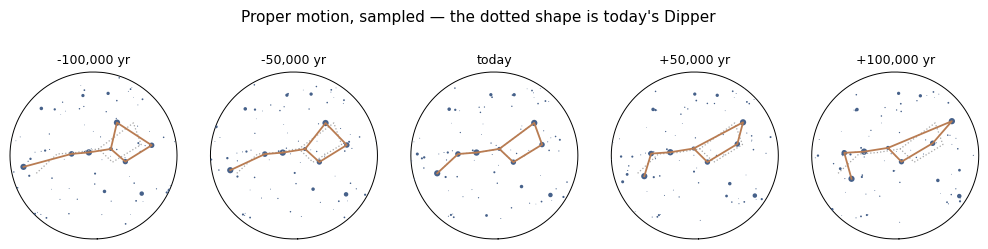

In [9]:
# fig-slug: dipper-filmstrip
fig = plt.figure(figsize=(12.5, 3.0))
for k, t in enumerate([-100_000, -50_000, 0, 50_000, 100_000]):
    ax = sph.make_wcs_frame(151 + k, projection="ZEA", center=(186, 55.5),
                            fov_deg=40, fig=fig, grid=False, tick_style="native")
    tr = ax.get_transform("world")
    ax.plot(g_ra, g_dec, color="0.65", lw=0.9, ls=":", transform=tr)
    ax.scatter(*propagate(uma, t), s=sizes * 0.45, color=C[0], lw=0, transform=tr)
    ax.plot(*propagate(uma.loc[DIPPER], t), color=C[1], lw=1.3, transform=tr)
    ax.set_title(f"{t:+,.0f} yr" if t else "today", fontsize=9)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
fig.suptitle("Proper motion, sampled — the dotted shape is today's Dipper", fontsize=11)
plt.show()

> **Note:** linear propagation is a *visualization*, not an ephemeris — it
> ignores radial velocity (stars approach and recede, so their angular speeds
> change) and treats the sky as locally flat. For rigorous work use
> `SkyCoord.apply_space_motion()`, which handles the full 3-D space motion.
> At this zoom level the difference wouldn't move a line by its own width.

The same recipe animates anything with a time axis in a catalog — asteroid
tracks, satellite passes, or ephemeris positions. For solar-system and
Earth-satellite work, [skyfield](https://rhodesmill.org/skyfield/) computes
the positions and skyplothelper draws them; the loop is identical:

```python
from skyfield.api import load
eph, ts = load("de421.bsp"), load.timescale()
days = ts.utc(2026, 7, range(1, 366))
astrometric = eph["earth"].at(days).observe(eph["mars barycenter"])
ra, dec, _ = astrometric.radec()          # -> update a scatter, frame by frame
```

### Stars around the black hole

Linear proper motion is the small-angle limit; the most extreme motions in
the Galaxy are anything but. A cluster of stars — the **S-stars** — races
around **Sgr A\***, the four-million-solar-mass black hole at the Galactic
center, on full Keplerian ellipses, the innermost swinging through pericenter
at a few percent of the speed of light. The decades of astrometry that pinned
those orbits down earned the 2020 Nobel Prize; the bundled `sstar_orbits.csv`
carries the orbital elements of the 16 best-measured (Gillessen et al. 2017 —
see the `examples/data` README).

With the elements in hand, a star's position at *any* epoch is closed-form:
solve Kepler's equation for the eccentric anomaly, then rotate the orbit
ellipse onto the sky with the Thiele–Innes constants. It's exact, and as
smooth as you care to sample — no integration, no interpolating between
observations.

In [10]:
import astropy.units as u  # noqa: E402, I001
from astropy.coordinates import SkyCoord  # noqa: E402
from matplotlib.cm import ScalarMappable  # noqa: E402
from matplotlib.collections import LineCollection  # noqa: E402
from matplotlib.colors import Normalize  # noqa: E402

SGRA = (266.41681, -29.00782)                      # Sgr A* (ICRS deg)
sstars = pd.read_csv(f"{DATA}/sstar_orbits.csv")


def kepler_E(mean_anom, ecc, n_iter=60):
    """Eccentric anomaly from mean anomaly, by Newton's method."""
    m = np.mod(mean_anom + np.pi, 2 * np.pi) - np.pi
    ea = m + ecc * np.sin(m)
    for _ in range(n_iter):
        ea -= (ea - ecc * np.sin(ea) - m) / (1 - ecc * np.cos(ea))
    return ea


def star_offsets(row, t_yr):
    """(ΔRA-east, ΔDec-north) arcsec offsets from Sgr A* at decimal year(s)."""
    a, e = row.a_arcsec, row.ecc
    inc, node, peri = np.radians([row.incl_deg, row.node_deg, row.periapsis_deg])
    ea = kepler_E(2 * np.pi * (t_yr - row.t_peri_yr) / row.period_yr, e)
    xe, ye = np.cos(ea) - e, np.sqrt(1 - e * e) * np.sin(ea)
    d_east = a * ((np.cos(peri) * np.sin(node) + np.sin(peri) * np.cos(node) * np.cos(inc)) * xe
                  + (-np.sin(peri) * np.sin(node) + np.cos(peri) * np.cos(node) * np.cos(inc)) * ye)
    d_north = a * ((np.cos(peri) * np.cos(node) - np.sin(peri) * np.sin(node) * np.cos(inc)) * xe
                   + (-np.sin(peri) * np.cos(node) - np.cos(peri) * np.sin(node) * np.cos(inc)) * ye)
    return d_east, d_north


def star_radec(row, t_yr):
    """ICRS (ra, dec) of an S-star — East offset *increases* RA (shown east-left)."""
    d_east, d_north = star_offsets(row, t_yr)
    ra = SGRA[0] + (d_east / 3600.0) / np.cos(np.radians(SGRA[1]))
    return ra, SGRA[1] + d_north / 3600.0


# Color each star by orbital period — `sph.mesa` keeps the fast inner stars
# legible on the navy where a blue-ended map would vanish — and size by K-band
# brightness. The full ellipse of each orbit is one period of the same math.
star_rows = list(sstars.itertuples())
periods = sstars.period_yr.to_numpy()
pnorm = Normalize(periods.min(), periods.max())
pmap = plt.get_cmap("sph.mesa")
star_colors = pmap(pnorm(periods))
star_sizes = np.clip((17.6 - np.nan_to_num(sstars.Kmag.to_numpy(), nan=17.0)) ** 2 * 10, 20, 230)
orbit_off = [np.column_stack(star_offsets(r, np.linspace(
    r.t_peri_yr, r.t_peri_yr + r.period_yr, 400))) for r in star_rows]
GC_FOV = 1.34 / 3600.0                              # deg — the field the orbits fill

### Offsets from Sgr A*, two ways

At this scale — a couple of arcseconds across — the sky is effectively flat,
and the natural display is *offsets from Sgr A\** rather than absolute RA/Dec
(every Ghez/Genzel figure is drawn this way). You can build that by hand on a
plain axes — invert the RA direction for east-left, label in arcsec, place a
compass — or let skyplothelper's offset tools do it on a *real* celestial
frame. Same picture; the sph side is a few purpose-built calls and folds the
absolute reference coordinate into the axis label for free:

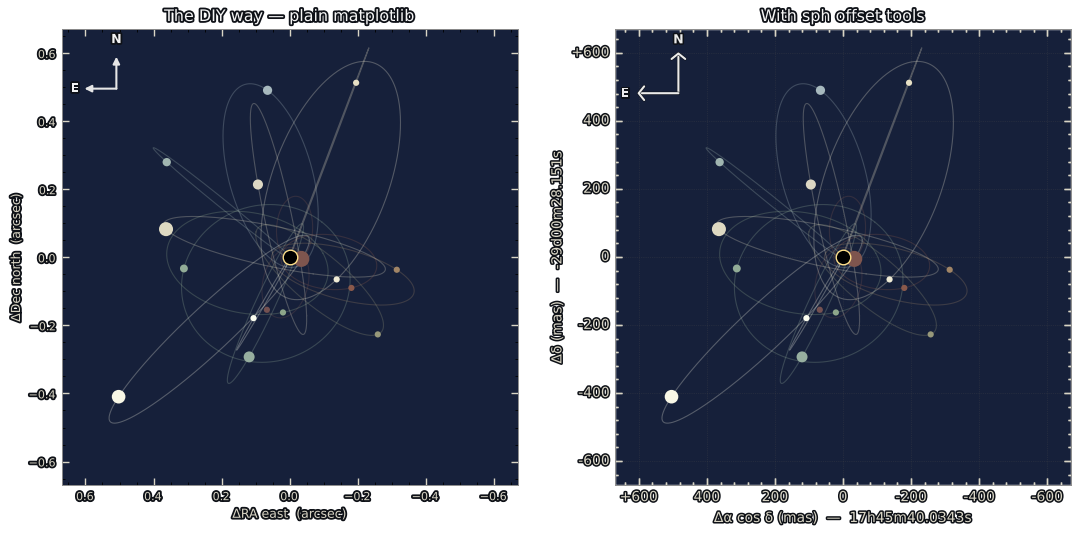

In [11]:
# fig-slug: gc-offsets-two-ways
now_off = np.array([star_offsets(r, 2018.0) for r in star_rows])     # dE, dN at 2018

fig = plt.figure(figsize=(11.4, 5.9))

# --- the DIY way: a plain axes, arcsec offsets, hand-built ---
axL = fig.add_subplot(121)
axL.set_position([0.065, 0.11, 0.40, 0.78])
axL.set_facecolor(SKY)
axL.set_xlim(0.67, -0.67)                          # invert x by hand -> East to the left
axL.set_ylim(-0.67, 0.67)
axL.set_aspect("equal")
axL.set_xlabel("ΔRA east  (arcsec)", fontsize=9, color="#D9D5C5", path_effects=GLOW)
axL.set_ylabel("ΔDec north  (arcsec)", fontsize=9, color="#D9D5C5", path_effects=GLOW)
axL.tick_params(colors="#D9D5C5", labelsize=8, width=1.0)
for _s in axL.spines.values():
    _s.set_color("#8C8C8C")
for _lab in axL.get_xticklabels() + axL.get_yticklabels():
    _lab.set_color("#D9D5C5")
    _lab.set_path_effects(GLOW)
for k, xy in enumerate(orbit_off):
    axL.plot(xy[:, 0], xy[:, 1], color=star_colors[k], lw=0.8, alpha=0.28)
axL.scatter([0], [0], s=110, c="black", edgecolors="#FFE08A", lw=1.0, zorder=9)
axL.scatter(now_off[:, 0], now_off[:, 1], s=star_sizes, c=star_colors, lw=0, zorder=8)
_cx, _cy, _cl = 0.12, 0.87, 0.07                   # a compass, by hand: N up, E left
_arw = dict(xycoords="axes fraction", textcoords="axes fraction",
            arrowprops=dict(arrowstyle="-|>", color="0.9", lw=1.5, shrinkA=0, shrinkB=0))
axL.annotate("", xy=(_cx, _cy + _cl), xytext=(_cx, _cy), **_arw)
axL.annotate("", xy=(_cx - _cl, _cy), xytext=(_cx, _cy), **_arw)
axL.text(_cx, _cy + _cl + 0.03, "N", transform=axL.transAxes, ha="center",
         fontsize=9, color="0.95", fontweight="bold", path_effects=GLOW)
axL.text(_cx - _cl - 0.03, _cy, "E", transform=axL.transAxes, va="center",
         fontsize=9, color="0.95", fontweight="bold", path_effects=GLOW)
axL.set_title("The DIY way — plain matplotlib", fontsize=11.5, color="0.96",
              path_effects=GLOW)

# --- the sph way: a real TAN frame + offset tools ---
axR = sph.make_wcs_frame(122, "TAN", center=SGRA, fov_deg=GC_FOV, npix=500,
                         fig=fig, grid=True, gridcolor="0.3")
axR.set_position([0.55, 0.11, 0.40, 0.78])
axR.set_facecolor(SKY)
sph.apply_offset_ticks(axR, unit="mas", spacing=200 * u.mas, show_unit=False,
                       stroke_color="#0E1117", stroke_lw=2.2, color="#D9D5C5")
for _c in (axR.coords[0], axR.coords[1]):
    _c.set_ticks(width=1.0, color="#D9D5C5")
axR.coords.frame.set_color("#8C8C8C")
_trR = axR.get_transform("world")
for k, xy in enumerate(orbit_off):
    ra = SGRA[0] + (xy[:, 0] / 3600) / np.cos(np.radians(SGRA[1]))
    axR.plot(ra, SGRA[1] + xy[:, 1] / 3600, transform=_trR,
             color=star_colors[k], lw=0.8, alpha=0.28)
axR.scatter([SGRA[0]], [SGRA[1]], s=110, c="black", edgecolors="#FFE08A", lw=1.0,
            transform=_trR, zorder=9)
_nra = SGRA[0] + (now_off[:, 0] / 3600) / np.cos(np.radians(SGRA[1]))
axR.scatter(_nra, SGRA[1] + now_off[:, 1] / 3600, s=star_sizes, c=star_colors,
            lw=0, transform=_trR, zorder=8)
sph.add_compass(axR, loc="upper left", length=0.09, color="0.92",
                stroke_color="#0E1117", stroke_lw=2.2, fontsize=9)
axR.set_title("With sph offset tools", fontsize=11.5, color="0.96", path_effects=GLOW)
plt.show()

The right panel is `sph.make_wcs_frame('TAN', center=SgrA, ...)` +
`sph.apply_offset_ticks(unit='mas', spacing=200*u.mas)` + `sph.add_compass()`:
because the frame stays a genuine celestial WCS, the stars go on by RA/Dec and
the ticks *read* as offsets, and `add_compass` gets the real sky orientation
(east-left) rather than a hand-placed guess. The plain-axes version is a fine
choice too — this is a flat field — it just does by hand what the offset tools
package up.

Now set it in motion. It's the Dipper's recipe once more — a scatter whose
positions update each frame — on the sph offset frame, with each star's orbit
as a faint period-colored trail and a comet tracer streaming from its head. A
`Ruler` gives the physical scale (arcseconds convert to light-days at the
Galactic center's distance), and a scrubber marks the year:

In [12]:
# fig-slug: sstar-orbits
gc_years = np.linspace(2000, 2026, 120)
gc_pos = np.array([[star_radec(r, y) for r in star_rows] for y in gc_years])  # (ny, n, 2)
Y0, Y1 = gc_years[0], gc_years[-1]

fig = plt.figure(figsize=(5.8, 6.4))
ax = sph.make_wcs_frame(111, "TAN", center=SGRA, fov_deg=GC_FOV, npix=500,
                        fig=fig, grid=True, gridcolor="0.3")
ax.set_position([0.175, 0.20, 0.74, 0.70])         # room for the y-label + scrubber
ax.set_facecolor(SKY)
# Warm off-white ticks + axis labels in one call: `show_unit=False` keeps the
# unit in the axis label only (bare numbers on the ticks), and `color`/`stroke`
# now style the axis labels as well as the ticks.
sph.apply_offset_ticks(ax, unit="mas", spacing=200 * u.mas, precision=0,
                       show_unit=False, color="#D9D5C5",
                       stroke_color="#0E1117", stroke_lw=2.2)
for _c in (ax.coords[0], ax.coords[1]):            # tick marks: a touch longer, ~1pt thinner
    _c.set_ticks(size=4.6, width=1.0, color="#D9D5C5")
ax.coords.frame.set_color("#8C8C8C")               # medium gray: reads on both pages
ax.coords.frame.set_linewidth(1.1)
tr = ax.get_transform("world")

for k, xy in enumerate(orbit_off):                 # faint period-colored orbits
    ra = SGRA[0] + (xy[:, 0] / 3600) / np.cos(np.radians(SGRA[1]))
    ax.plot(ra, SGRA[1] + xy[:, 1] / 3600, transform=tr,
            color=star_colors[k], lw=0.8, alpha=0.28, zorder=1)
ax.scatter([SGRA[0]], [SGRA[1]], s=380, c="none", edgecolors="#FFE08A",
           linewidths=0.4, alpha=0.35, transform=tr, zorder=8)   # halo
ax.scatter([SGRA[0]], [SGRA[1]], s=130, c="black", edgecolors="#FFE08A",
           linewidths=1.1, transform=tr, zorder=9)               # the black hole
sph.add_compass(ax, loc="upper left", length=0.085, color="0.92",
                stroke_color="#0E1117", stroke_lw=2.2, fontsize=9)

sm = ScalarMappable(norm=pnorm, cmap=pmap)
sm.set_array([])
cax = fig.add_axes([0.845, 0.28, 0.018, 0.18])
cb = sph.add_colorbar(sm, ax, cax=cax)
cb.ax.yaxis.set_ticks_position("left")
cb.ax.yaxis.set_label_position("left")
cb.set_label("orbital period (yr)", fontsize=7.5, color="0.9")
cb.ax.tick_params(labelsize=7, colors="0.85")

# sph.Ruler as a physical scale bar (0.2″ ≈ 9.6 light-days at R0 = 8.3 kpc),
# centered along the bottom (± 0.1″ about Sgr A*), with the wordmark in the corner
_c1 = SkyCoord(SGRA[0] + (0.10 / 3600) / np.cos(np.radians(SGRA[1])), SGRA[1] - 0.55 / 3600, unit="deg")
_c2 = SkyCoord(SGRA[0] + (-0.10 / 3600) / np.cos(np.radians(SGRA[1])), SGRA[1] - 0.55 / 3600, unit="deg")
sph.Ruler(_c1, _c2, ax=ax, n_ticks=2, tick_length=0, endcap_style="none",
          labels=False, color="0.85", lw=2.2, title="0.2″  ≈  9.6 light-days",
          title_color="0.88", title_fontsize=8, title_offset=4,
          stroke_color="#0E1117", stroke_lw=2.2).add_to(ax)

tails = LineCollection([], zorder=6, transform=tr)
ax.add_collection(tails)
dots = ax.scatter(gc_pos[0, :, 0], gc_pos[0, :, 1], s=star_sizes, c=star_colors,
                  lw=0, transform=tr, zorder=7)
yrlbl = ax.text(0.97, 0.97, "", transform=ax.transAxes, ha="right", va="top",
                fontsize=14, color="0.97", family="monospace", path_effects=GLOW)
ax.set_title("The S-stars orbiting Sgr A*", fontsize=12.5, color="0.96",
             path_effects=GLOW, pad=10)

# a time scrubber below the frame — an opaque track, a sliding knob, the year at
# each tick (WebP redraws each frame whole, so a knob in the margin can't trail)
SX0, SX1, SY = 0.06, 0.94, -0.185
ax.plot([SX0, SX1], [SY, SY], transform=ax.transAxes, color="#20293F", lw=11,
        solid_capstyle="round", zorder=2, clip_on=False)
ax.plot([SX0, SX1], [SY, SY], transform=ax.transAxes, color="0.42", lw=2.2,
        solid_capstyle="round", zorder=3, clip_on=False)
for _yt in range(2000, 2026, 5):
    _fx = SX0 + (SX1 - SX0) * (_yt - Y0) / (Y1 - Y0)
    ax.plot([_fx, _fx], [SY - 0.013, SY + 0.013], transform=ax.transAxes,
            color="0.62", lw=1.0, zorder=3, clip_on=False)
    ax.text(_fx, SY - 0.032, f"{_yt}", transform=ax.transAxes, ha="center",
            va="top", fontsize=7.5, color="0.82", clip_on=False, path_effects=GLOW)
progress, = ax.plot([SX0, SX0], [SY, SY], transform=ax.transAxes, color="#FFD86B",
                    lw=2.8, solid_capstyle="round", zorder=4, clip_on=False)
knob = ax.scatter([SX0], [SY], transform=ax.transAxes, s=66, c="#FFD86B",
                  edgecolors="#0E1117", linewidths=0.8, zorder=5, clip_on=False)


def update(i):
    dots.set_offsets(gc_pos[i])
    segs, cols, lws = [], [], []
    for k in range(len(star_rows)):
        pts = gc_pos[max(0, i - 20):i + 1, k, :]   # a 20-frame comet tail
        m = len(pts) - 1
        for s in range(m):
            segs.append([pts[s], pts[s + 1]])
            frac = (s + 1) / m                      # 0 = tail end, 1 = at the star
            cols.append((*star_colors[k][:3], frac ** 1.6))
            lws.append(0.5 + 2.9 * frac)            # comet taper
    tails.set_segments(segs)
    tails.set_color(cols)
    tails.set_linewidths(lws)
    yrlbl.set_text(f"{gc_years[i]:.1f}")
    _fx = SX0 + (SX1 - SX0) * (gc_years[i] - Y0) / (Y1 - Y0)
    progress.set_data([SX0, _fx], [SY, SY])
    knob.set_offsets([[_fx, SY]])


ani = FuncAnimation(fig, update, frames=len(gc_years), interval=55)
add_logo(fig, 0.185, 0.215, width=0.24)     # lower-left corner (scale bar moves to center below)
save_anim(ani, fig, "sstar-orbits", fps=20, dpi=84, lossless=True)  # thin orbit lines -> lossless wins

animations__sstar-orbits.webp: 1.15 MB


![The S-stars racing around the Galactic-center black hole, 2000 to 2026](../_static/animations/animations__sstar-orbits.webp)

The inner stars blur through pericenter and crawl at apocenter — Kepler's
second law made visible — while the black hole itself never moves. This is the
figure the UCLA and GRAVITY groups built from a decade of imaging; here it
falls out of sixteen rows of orbital elements and a dozen lines of Kepler.
Coloring by *radial velocity* instead of period, or dropping the measured
astrometric points onto the model tracks, are each a column away.

> **Note:** these are *osculating* Keplerian orbits — they ignore the tiny
> relativistic pericenter precession GRAVITY detected in S2 (far below a pixel
> here). And for the reader with their hand on the clock rather than a fixed
> loop, the same data drives a slider-driven **plotly** version beautifully —
> positions are closed-form in time, so there are no frames to pre-bake.

## 4. Rotating planets

Now the second update pattern: animating **the view itself**. A globe frame's
WCS encodes where it points — mutate the pointing per frame, re-drape the
surface texture, and the planet turns. The essence of that loop, in
schematic form:

```python
ax.wcs.wcs.crval = [lon_i, lat_i]          # re-aim the frame...
ax.wcs.wcs.lonpole = pole_i                # ...and its roll
hdr = ax.wcs.to_header(); hdr["NAXIS1"] = nx; hdr["NAXIS2"] = ny
img.set_array(sph.reproject_rgb_map(texture_hdu, hdr))
```

— but the bookkeeping around that sketch (output shapes, redraws, label
upkeep) is exactly what the package wraps for you: `animate_globe()`, the
helper that spun Mars in the opener, takes *sequences* of frame angles plus
a texture and does the rest. (Its import comes from the `globe.animation`
submodule rather than the top level — these are self-contained convenience
helpers built on top of the plotting functions, so they live one door down.)

Where do the angle sequences come from? `make_globe_angles()` — give it a
starting orientation `[rotation, obliquity, perspective]` (the same Euler
convention as the **Globe & Planet Plotting** tutorial) and per-step rates
for the three classical motions:

| Motion | Knob | What it looks like |
|--------|------|--------------------|
| **spin** | `spin_rate` (deg/step) | the surface turns past you |
| **nutation** | `nut_amp` (deg of nod) at `nut_rate` (deg of cycle phase/step) | the axis nods up and down |
| **precession** | `prec_rate` (deg/step) | the axis sweeps a cone |

It returns the `(center_lons, center_lats, lonpoles)` triple that
`animate_globe` (and any globe frame) consumes. One full turn of the Moon,
at its real 6.7-degree obliquity from the bundled `obliquities` table:

In [13]:
moon_hdu = sph.pseudofits_from_image(f"{DATA}/planet_maps/2k_moon.jpg", geo=True)

n = 36
lons, lats, poles = sph.make_globe_angles([0, sph.obliquities["moon"], 0],
                                          n, spin_rate=360 / n)
animate_globe(lons, lats, poles, bgim=moon_hdu,
              show_ticklabels=False, savepath=f"{ANIM}/animations__moon-spin.webp",
              bgcolor="transparent", webp_lossless=False,
              frame_kwargs={"direction": "geographic", "Naxispix": 360,
                            "tick_style": "native",
                            "gridcolor": "#33475C", "gridalpha": 0.55},
              dpi=round(80 * SIZE_BUMP), figsize=(4.6, 4.6))

![The Moon making one full rotation](../_static/animations/animations__moon-spin.webp)

The far side rotates into view — the part no one on Earth had seen before
1959 — and the graticule rides the surface with it.

> **Note:** `animate_globe` builds its globe internally, so frame options go
> through `frame_kwargs=` (anything `make_globe_frame()` accepts). The one
> that *matters* for a solid body is `direction='geographic'` — a planet's
> surface runs east-*right*, and the sky-oriented default would mirror the
> map (see the Globe tutorial). The `tick_style='native'` here is purely
> cosmetic: with the labels off it also drops the in-frame tick dashes, for
> a fully bare disk.

What do the three motions look like *in motion*? Here they are side by side on
a night-lit **Earth** — the body that carries all three, and the one geodesy
actually tracks — each with a rod through the poles (`add_pole_rod`, the Globe
tutorial's decoration) so the *axis* is legible at a glance. Each panel turns
the Earth the way it really turns (eastward) and precesses the way it really
precesses (a slow *retrograde* cone); the precession view is tipped a little
off the axis, so the rod's tip traces an **oblique ellipse** — a cone seen in
perspective — rather than a flat, ambiguous circle:

In [14]:
# fig-slug: three-motions


def drape(ax, hdu):
    """Resample an equirectangular texture onto a globe frame (as in the Globe tutorial)."""
    hdr = ax.wcs.to_header()
    nx = round(ax.get_xlim()[1] - ax.get_xlim()[0])
    ny = round(ax.get_ylim()[1] - ax.get_ylim()[0])
    hdr["NAXIS1"], hdr["NAXIS2"] = nx, ny
    return ax.imshow(np.nan_to_num(
        sph.reproject_rgb_map(hdu, hdr, shape_out=(ny, nx))), zorder=-10)


earthnight_hdu = sph.pseudofits_from_image(f"{DATA}/BlackMarble_2016_01deg.jpg", geo=True)

# All three share one moderate look-down; each sweeps a different piece of the
# orientation. The directions are Earth's real ones: the surface turns eastward,
# and the axis precesses *retrograde* (the note below spells this out).
n = 24
CLAT = 48
_ph = 2 * np.pi * np.arange(n) / n


def _rot(axis, angle_deg):
    """Rotation matrix about an arbitrary axis (Rodrigues)."""
    a = np.asarray(axis, float)
    a = a / np.linalg.norm(a)
    t = np.radians(angle_deg)
    K = np.array([[0, -a[2], a[1]], [a[2], 0, -a[0]], [-a[1], a[0], 0]])
    return np.eye(3) * np.cos(t) + np.sin(t) * K + (1 - np.cos(t)) * np.outer(a, a)


def precession_sweep(n, obl=15.0, beta=32.0):
    """Frame angles for the spin axis coning about the ecliptic pole.

    This is one *rigid* rotation of the whole body (no spin), so the sweep runs
    smoothly the whole way round. Deriving all three frame angles from that one
    matrix is what keeps it smooth: pinning ``center_LONdeg`` to hold one face
    forward is not a rigid motion, and it snaps as the pole swings past the
    viewer. ``obl`` is the cone's half-angle (how wide a circle the axis traces);
    ``beta`` tips the cone axis off the line of sight, so the rod's tip traces a
    visible *ellipse* — a cone in perspective — rather than a flat, ambiguous
    circle. The minus sign on the sweep makes it run clockwise seen from the
    north: Earth's real *retrograde* precession of the equinoxes.

    Returns the three frame angles plus the spin-axis unit vectors in camera
    coordinates, which the still below uses to draw the rod tip's own path.
    """
    e = np.array([0.0, np.sin(np.radians(beta)), np.cos(np.radians(beta))])  # ecliptic pole
    tilt = np.cross(e, [0.0, 0.0, 1.0])
    tilt /= np.linalg.norm(tilt)
    axis0 = _rot(tilt, obl) @ e                       # spin axis, obl off the cone axis
    z = np.array([0.0, 0.0, 1.0])
    v = np.cross(z, axis0)
    s = np.linalg.norm(v)
    r0 = np.eye(3) if s < 1e-9 else _rot(v / s, np.degrees(np.arctan2(s, z @ axis0)))
    lons, lats, poles, axes = [], [], [], []
    for i in range(n):
        rot = _rot(e, -360.0 * i / n) @ r0            # minus -> retrograde
        ncam = rot[:, 2]                              # spin axis, camera coords
        sub = rot.T @ z                               # sub-observer point, body coords
        lons.append(np.degrees(np.arctan2(sub[1], sub[0])))
        lats.append(np.degrees(np.arcsin(np.clip(ncam[2], -1, 1))))
        poles.append(np.degrees(np.arctan2(ncam[1], ncam[0])) - 90)   # calibrated azimuth
        axes.append(ncam)
    return np.array(lons), np.array(lats), np.array(poles), np.array(axes)


_plon, _plat, _ppole, _ = precession_sweep(n)
motions = [
    # spin: the sub-observer longitude runs *down*, so the surface turns eastward
    # (the way Earth spins) under a rod that never moves.
    ("spin",       (20 - np.linspace(0, 360, n, endpoint=False), np.full(n, CLAT), np.zeros(n))),
    # nutation: the view nods in latitude — the rod tips toward and away.
    ("nutation",   (np.full(n, 20.0), CLAT + 14 * np.sin(_ph), np.zeros(n))),
    # precession: the whole body cones rigidly about the ecliptic pole, so the rod
    # tip walks an ellipse (retrograde, as Earth's axis really does).
    ("precession", (_plon, _plat, _ppole)),
]


def motion_panel(idx, lon, lat, pole, title):
    ax = sph.make_planet_frame((1, 3, idx), body="earth",
                               center_LONdeg=lon, center_LATdeg=lat, lonpole=pole,
                               Naxispix=200, tick_style="native",
                               gridcolor="#7A9BBF", gridalpha=0.55)
    ax.set_facecolor(SKY)                     # rods sweep beyond the disk, over opaque navy
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    drape(ax, earthnight_hdu)
    sph.add_pole_rod(ax, length=1.5)          # tip at 1.5 R: the rod protrudes past the pole
    ax.set_title(title, fontsize=12, color="0.95", path_effects=GLOW)


fig = plt.figure(figsize=(10.5, 3.8))


def update(i):
    fig.clear()
    for k, (name, (los, las, pos)) in enumerate(motions):
        motion_panel(k + 1, los[i], las[i], pos[i], name)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.87, bottom=0.02, wspace=0.05)


ani = FuncAnimation(fig, update, frames=n, interval=90)
# A solid navy card (not transparent): the three globes share one panel, so a
# single card reads as one scene — and still sits on light and dark pages alike —
# rather than three disks floating with the page showing through the gaps.
save_anim(ani, fig, "three-motions", fps=10, dpi=74, bg=SKY)

animations__three-motions.webp: 0.44 MB


![Earth's night side under each of the three classical motions, side by side](../_static/animations/animations__three-motions.webp)

Read each panel off its rod: **spin** slides the surface eastward past a rod
that never moves; **nutation** nods the rod toward and away; **precession**
walks the rod's tip around an **oblique ellipse** — the axis tracing out its
cone in perspective, in the slow *retrograde* sense that is Earth's own. (There
is no spin in that third panel: the whole body cones *rigidly*, so the face you
see drifts only because the axis is leading it around, and the south rod sweeps
its own circle below in the same cadence.) That
cone is what Earth's rotation axis actually does on the sky over ~26,000
years (the precession of the equinoxes), with real nutation a small
~18.6-year nod on top — tracking it to the millimeter is part of the business of
geodesy, and the day/night Earth of §5 and §8 is this same body still turning.

> **A terminology footnote.** *Precession* and *nutation* mean subtly
> different things to an engineer and to an astronomer. In **rigid-body
> mechanics** they are two of the Euler angles: precession is rotation of the
> spin axis about the vertical, nutation the *tilt angle* between them (the
> angles this figure sweeps one at a time). In **astronomy** they name the
> *observed* motions of Earth's axis — precession the slow 26,000-year cone,
> nutation the periodic wobble (chiefly ~18.6-year, from the Moon) riding on
> top of it. Same geometry, named for different pieces of it.

For print, the three motions as a still — each with an arrow for its motion.
The precession arrow is the literal one: it starts at the rod tip and traces the
ellipse that tip walks over a full cycle.

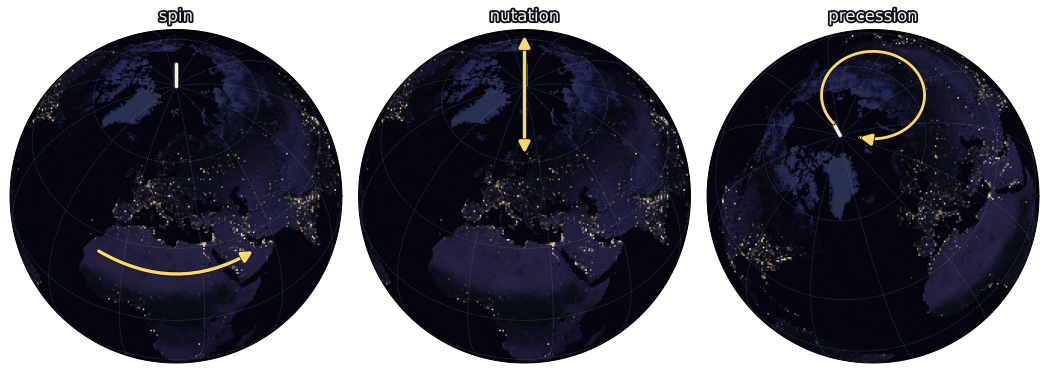

In [15]:
# fig-slug: three-motions-arrows
from matplotlib.patches import FancyArrowPatch  # noqa: E402

_ARROW = "#FFD86B"
_akw = dict(color=_ARROW, lw=2.4, mutation_scale=16, zorder=25,
            path_effects=[pe.withStroke(linewidth=3.5, foreground="#0E1117")])
_ROD = 1.2                       # shorter than the movie's, so the tip's path fits the panel
_STEPS = 72                      # smooth trace of one precession cycle
_AT = 10                         # which step of that cycle the still freezes at

# The precession panel freezes one step of the *same* sweep the movie plays, so
# its rod sits off vertical; spin and nutation keep the shared look-down and let
# the arrows do the differentiating.
_slon, _slat, _spole, _saxis = precession_sweep(_STEPS)
poses = {"spin": (20, CLAT, 0), "nutation": (20, CLAT, 0),
         "precession": (_slon[_AT], _slat[_AT], _spole[_AT])}

fig = plt.figure(figsize=(10.5, 4.0))
for k, name in enumerate(["spin", "nutation", "precession"]):
    center_lon, center_lat, lonpole = poses[name]
    ax = sph.make_planet_frame((1, 3, k + 1), body="earth", center_LONdeg=center_lon,
                               center_LATdeg=center_lat, lonpole=lonpole, Naxispix=220,
                               tick_style="native", gridcolor="#7A9BBF", gridalpha=0.55)
    ax.set_facecolor(SKY)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    drape(ax, earthnight_hdu)
    sph.add_pole_rod(ax, length=_ROD)
    ax.set_title(name, fontsize=12, color="0.95", path_effects=GLOW)
    if name == "spin":                    # eastward, bowing down along a front parallel
        ax.add_patch(FancyArrowPatch((0.26, 0.34), (0.74, 0.34), transform=ax.transAxes,
                     connectionstyle="arc3,rad=0.30", arrowstyle="-|>", **_akw))
    elif name == "nutation":              # double-headed nod at the pole
        ax.add_patch(FancyArrowPatch((0.5, 0.62), (0.5, 0.99), transform=ax.transAxes,
                     arrowstyle="<|-|>", **_akw))
    else:
        # Trace the path the rod tip itself walks over one cycle. A SIN globe
        # scales the (pole − center) vector by the rod length, so the tip of the
        # axis at step i lands at center + _ROD·R·(x, y) of that step's axis
        # vector — an ellipse, the cone seen in perspective.
        xc = float(ax.wcs.wcs.crpix[0]) - 1.0
        yc = float(ax.wcs.wcs.crpix[1]) - 1.0
        _px, _py = ax.wcs.wcs_world2pix(np.array([[0.0, 90.0]]), 0)[0]
        r_pix = (_py - yc) / _saxis[_AT][1]                     # body radius in pixels
        (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
        track = np.array([(((xc + _ROD * r_pix * a[0]) - x0) / (x1 - x0),
                           ((yc + _ROD * r_pix * a[1]) - y0) / (y1 - y0)) for a in _saxis])
        track = track[np.roll(np.arange(_STEPS), -_AT)][:int(_STEPS * 0.93)]  # start at the tip
        ax.plot(track[:, 0], track[:, 1], transform=ax.transAxes, color=_ARROW, lw=2.0,
                zorder=25, solid_capstyle="round",
                path_effects=[pe.withStroke(linewidth=3.2, foreground="#0E1117")])
        ax.add_patch(FancyArrowPatch(tuple(track[-2]), tuple(track[-1]),
                     transform=ax.transAxes, arrowstyle="-|>", **_akw))
fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.02, wspace=0.05)
plt.show()

## 5. Day and night in motion

The **Globe & Planet Plotting** tutorial builds a day/night Earth by blending
a nighttime city-lights map over a daytime one along the terminator
(`make_nightshade_blend`) — for one frozen instant. But the terminator is the
most naturally *animated* thing there is: give `animate_blended_globe()` a
sequence of timestamps alongside the frame angles and it recomputes the
blend per frame, so the day/night line actually crawls.

The two source maps are large local rasters (NASA's Blue Marble topography
and Black Marble city lights) — and per §1's size rule, a movie doesn't need
5400-pixel sources. Downsample once, up front:

In [16]:
import tempfile  # noqa: E402

TMP = tempfile.gettempdir()
for src, dst in [(f"{DATA}/world.topo.bathy.200412.3x5400x2700.jpg", f"{TMP}/earth_day_1024.jpg"),
                 (f"{DATA}/BlackMarble_2016_01deg.jpg", f"{TMP}/earth_night_1024.jpg")]:
    Image.open(src).resize((1024, 512), Image.LANCZOS).save(dst, quality=90)

day_hdu = sph.pseudofits_from_image(f"{TMP}/earth_day_1024.jpg", geo=True)
night_hdu = sph.pseudofits_from_image(f"{TMP}/earth_night_1024.jpg", geo=True)

Hold the view fixed over the Americas and let one day elapse — the June
solstice, so the terminator leans at its steepest and the Arctic never quite
goes dark:

In [17]:
from datetime import datetime, timedelta  # noqa: E402

from skyplothelper.globe.animation import animate_blended_globe  # noqa: E402

n = 36
view = np.full(n, 280.0), np.full(n, 15.0), np.zeros(n)   # fixed lons/lats/poles
solstice = [datetime(2026, 6, 20, 0, 0) + timedelta(hours=24 / n * i)
            for i in range(n)]

animate_blended_globe(*view, solstice, day_hdu, night_hdu,
                      savepath=f"{ANIM}/animations__terminator-sweep.webp",
                      bgcolor="transparent", webp_lossless=False,
                      frame_kwargs={"direction": "geographic", "Naxispix": 360},
                      dpi=round(80 * SIZE_BUMP), figsize=(5.0, 5.0))

![The day/night terminator sweeping across the Americas over 24 hours](../_static/animations/animations__terminator-sweep.webp)

The city lights do the storytelling: the eastern seaboard blinks on as the
terminator passes, and the Amazon stays dark long after the coasts wake up.
Two knobs worth knowing (both forwarded from `make_nightshade_blend` — the
Globe tutorial has the full tour): `blend='elevation'` (the default) makes
the transition span the *physical* twilight band, so its width means
something; `nightshade_kwargs={'curve': 'twilight'}` softens it further into
the civil/nautical/astronomical stages. (The stroke-outlined coordinate
labels come styled for imagery out of the box; restyle them via
`lon_label_props=` / `lat_label_props=` — `[text_color, stroke_color,
fontsize, stroke_lw]`.) The same sweep as stills:

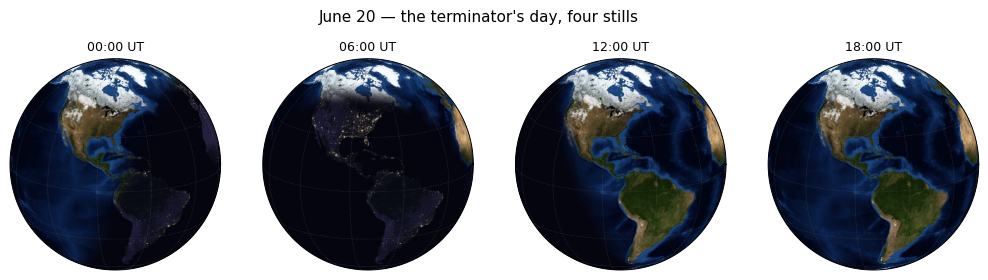

In [18]:
# fig-slug: terminator-filmstrip
night_img = night_hdu.data / 255.0
fig = plt.figure(figsize=(12.5, 3.2))
for k, i in enumerate([0, 9, 18, 27]):
    ax = sph.make_planet_frame((1, 4, k + 1), body="earth",
                               center_LONdeg=280, center_LATdeg=15,
                               Naxispix=300, tick_style="native",
                               gridcolor="0.6", gridalpha=0.3)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    drape(ax, day_hdu)
    night_rgba = sph.make_nightshade_blend(night_img, solstice[i])
    drape(ax, fits.ImageHDU(night_rgba, night_hdu.header))
    ax.set_title(solstice[i].strftime("%H:%M UT"), fontsize=9)
fig.suptitle("June 20 — the terminator's day, four stills", fontsize=11)
plt.show()

## 6. The Sun across the year

Back on the celestial sphere, the animation most observers actually need:
**where is the Sun, and what is it blocking?** Every proposal season the same
question comes up — *when* can this target be observed? — and the answer depends on
the time. The Sun tracks the ecliptic once a year, and it drags a
**solar-avoidance zone** with it (here 45 degrees, a particular radio-telescope
limit; you can repeat this for your own instrument). A target inside the ring of avoidance should not be scheduled for your observations at that time.

The moving ring is the `wrap_split` helper from §1 again — a `small_circle`
around the Sun, redrawn each week — and each target's marker answers the
question at a glance, flipping color as the ring rolls over it:

In [19]:
import astropy.units as u  # noqa: E402  (imported where the ephemeris work begins)
from astropy.coordinates import get_sun  # noqa: E402
from astropy.time import Time  # noqa: E402

weeks = Time("2026-01-01") + np.arange(52) * 7 * u.day
sun = get_sun(weeks)
sun_ra, sun_dec = sun.ra.deg, sun.dec.deg

TARGETS = {"Crab":    ( 83.63,  22.01),
           "3C 273":  (187.28,   2.05),
           "Sgr A*":  (266.42, -29.01),
           "Vega":    (279.23,  38.78),
           "M31":     ( 10.68,  41.27)}
t_ra = np.array([v[0] for v in TARGETS.values()])
t_dec = np.array([v[1] for v in TARGETS.values()])
AVOID = 45.0                                     # deg — solar-avoidance radius

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(7.6, 4.3))
    ax = sph.make_wcs_frame(111, projection="AIT", center=180, fig=fig)
    ax.set_facecolor(SKY)              # opaque sky ellipse; figure exterior floats transparent
    fig.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.08)
    # The Sun icon is an AnnotationBbox — it can't be clipped to the frame, so at
    # the RA-0 cusps it overhangs the ellipse into the transparent figure margin.
    # WebP redraws each frame whole (no GIF-style ghost), so the overhang just
    # floats cleanly on the page — no backing ellipse needed (a transparent GIF
    # used to need one here, since it kept those margin pixels frame to frame).
    sph.format_ticklabels(ax, fontsize=8, color="0.9",
                          stroke_color="#0E1117", stroke_lw=2.4)
    tr = ax.get_transform("world")
    sph.add_plane_overlay(ax, plane="ecliptic", color="0.7", lw=0.8, alpha=0.7)

    dots = ax.scatter(t_ra, t_dec, s=42, color="w", lw=0, transform=tr, zorder=5)
    for name, (ra_, dec_) in TARGETS.items():
        ax.text(ra_ + 4, dec_ + 5, name, transform=tr, fontsize=8.5,
                color="0.92", ha="right", path_effects=GLOW)
    # A mini Sun icon (the imscatter family, see the Markers tutorial) instead
    # of a plain dot. imscatter places in pixel coords, so project the Sun's
    # (RA, Dec) through the frame WCS; the returned AnnotationBbox then moves
    # each frame via its `.xybox`/`.xy`.
    _sx, _sy = ax.wcs.world_to_pixel_values(sun_ra[0], sun_dec[0])
    sun_icon = sph.imscatter([float(_sx)], [float(_sy)], f"{DATA}/icons/sun2_120pix.png",
                             ax=ax, zoom=0.33, zorder=6)[0]
    ring, = ax.plot([], [], color="gold", lw=1.3, alpha=0.9, transform=tr)
    # The date drifts frame to frame, so it rides *on* the opaque sky.
    datelbl = ax.text(0.5, 0.96, "", transform=ax.transAxes, ha="center",
                      va="top", fontsize=11, color="0.95", family="monospace",
                      path_effects=GLOW)
    ax.set_title("The 45-degree solar-avoidance zone, week by week", fontsize=11,
                 pad=14, color="0.95", path_effects=GLOW)

    def update(i):
        px, py = ax.wcs.world_to_pixel_values(sun_ra[i], sun_dec[i])
        sun_icon.xybox = sun_icon.xy = (float(px), float(py))
        ring.set_data(*wrap_split(*sph.small_circle(sun_ra[i], sun_dec[i], AVOID,
                                                    n_pts=241)))
        sep = np.array([sph.angulardistance((sun_ra[i], sun_dec[i]), (r, d))
                        for r, d in zip(t_ra, t_dec)])
        dots.set_color(np.where(sep < AVOID, "#E06152", "w"))
        datelbl.set_text(weeks[i].datetime.strftime("%Y %b %d"))

    ani = FuncAnimation(fig, update, frames=len(weeks), interval=120)
    add_logo(fig, 0.37, 0.10, width=0.26)       # low-center, on the navy ellipse
    save_anim(ani, fig, "sun-avoidance", fps=7, dpi=75)  # filled zone -> lossy is smaller

animations__sun-avoidance.webp: 0.50 MB


![The solar-avoidance zone sweeping the sky over a year](../_static/animations/animations__sun-avoidance.webp)

The ecliptic targets take the biggest hit: the Crab Nebula is flagged from May through July
and 3C 273 August through November, Sgr A* loses the weeks around the
December solstice — and even M31, forty degrees north of the ecliptic, gets
clipped each spring (the ring's closest pass is 33 degrees). Only Vega, never
nearer than 62 degrees, keeps its marker white all year. That is a target's
observability calendar, read straight off the sky. The four seasons, as
stills:

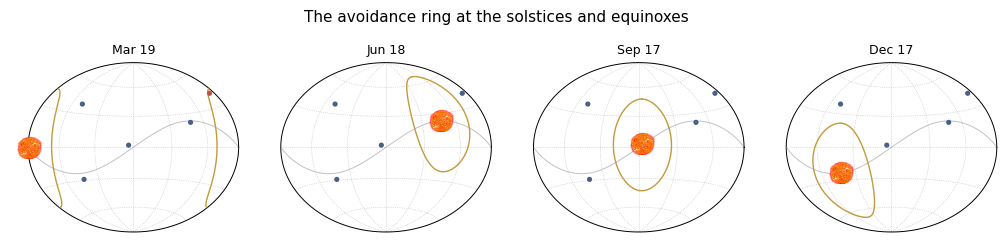

In [20]:
# fig-slug: sun-avoidance-filmstrip
fig = plt.figure(figsize=(12.5, 2.2))
season_idx = [11, 24, 37, 50]                    # ~equinoxes & solstices
for k, i in enumerate(season_idx):
    ax = sph.make_wcs_frame(141 + k, projection="AIT", center=180, fig=fig,
                            tick_style="native")
    tr = ax.get_transform("world")
    sph.add_plane_overlay(ax, plane="ecliptic", color="0.6", lw=0.7, alpha=0.6)
    sep = np.array([sph.angulardistance((sun_ra[i], sun_dec[i]), (r, d))
                    for r, d in zip(t_ra, t_dec)])
    ax.scatter(t_ra, t_dec, s=14, c=np.where(sep < AVOID, "#C24F43", C[0]),
               lw=0, transform=tr, zorder=5)
    _sx, _sy = ax.wcs.world_to_pixel_values(sun_ra[i], sun_dec[i])
    sph.imscatter([float(_sx)], [float(_sy)], f"{DATA}/icons/sun2_120pix.png",
                  ax=ax, zoom=0.16, zorder=6)
    ax.plot(*wrap_split(*sph.small_circle(sun_ra[i], sun_dec[i], AVOID, n_pts=241)),
            color=C[2], lw=1.0, transform=tr)
    ax.set_title(weeks[i].datetime.strftime("%b %d"), fontsize=9)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
fig.suptitle("The avoidance ring at the solstices and equinoxes", y=1.12, fontsize=11)
plt.show()

## 7. Co-visibility over a sidereal day

The **Vector Fields** tutorial closed with the co-visibility toolkit: the
patch of sky a whole network of stations can see *right now*
(`covisibility_region`), and the declination band it can hold for at least
N hours per day (`covisibility_duration_band`). The band is a
*time-integrated* statement — and the connection between the two only really
clicks when you watch the clock run.

So: the same six-station global array, one sidereal day, one snapshot per
40 minutes. The instantaneous region — sky at least 15° above the horizon
(`el_min=15`) for **at least 3** of the six stations — slides westward with
the sky, and each station's **zenith point** rides along as a small
triangle (`covisibility_circles` hands back each cap's center): a lobe
lives wherever three or more triangles bunch together. The dashed line
never moves, because it is the *time-integrated* southern limit —
everything north of it is co-visible 4+ hours a day, all the way to the
pole (the array is northern-heavy, so the northern trio keeps the polar cap
in view around the clock). Watch 3C 273 — its marker flips as the region
crosses it, and the fraction of frames it spends lit, times 24 hours, reads
off its daily co-visible time:

In [21]:
ARRAY = {"VLA":            {"lat": 34.1,  "lon": -107.6},
         "Effelsberg":     {"lat": 50.5,  "lon": 6.9},
         "ATCA":           {"lat": -30.3, "lon": 149.6},
         "Hartebeesthoek": {"lat": -25.9, "lon": 27.7},
         "Kokee":          {"lat": 22.1,  "lon": -159.7},
         "Sheshan":        {"lat": 31.1,  "lon": 121.2}}
QSO = (187.28, 2.05)                              # 3C 273

t0 = Time("2026-07-02T00:00:00")
n_step = 36
sidereal_day = 23.9345 * u.hour
steps = t0 + np.arange(n_step) / n_step * sidereal_day

with sph.style_context(theme="dark_sky"):
    fig = plt.figure(figsize=(7.6, 4.3))
    ax = sph.make_wcs_frame(111, projection="AIT", center=180, fig=fig)
    ax.set_facecolor(SKY)              # opaque sky; figure exterior is transparent
    fig.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.08)
    sph.format_ticklabels(ax, fontsize=8, color="0.9",
                          stroke_color="#0E1117", stroke_lw=2.4)
    tr = ax.get_transform("world")

    band = sph.covisibility_duration_band(ax, ARRAY, min_hours=4.0,
                                          el_min=15, min_stations=3)
    band.render(facecolor="none", edgecolor=C[2], lw=1.2, linestyle="--")

    qso, = ax.plot([QSO[0]], [QSO[1]], "o", ms=7, color="w", mec="none",
                   transform=tr, zorder=6)
    ax.text(QSO[0] + 4, QSO[1] + 6, "3C 273", transform=tr, fontsize=9,
            color="0.92", ha="right", path_effects=GLOW)
    # One triangle per station, at its zenith — updated each frame.
    zeniths = ax.scatter([], [], s=22, marker="^", color="#8FB4E3", lw=0,
                         transform=tr, zorder=6)
    # The clock readout drifts, so it rides *on* the opaque sky.
    utlbl = ax.text(0.5, 0.96, "", transform=ax.transAxes, ha="center",
                    va="top", fontsize=11, color="0.95", family="monospace",
                    path_effects=GLOW)
    ax.set_title("Sky co-visible to at least 3 of 6 stations", fontsize=11,
                 pad=14, color="0.95", path_effects=GLOW)

    prev = []

    def update(i):
        # render() hands back every artist it drew, so the previous frame's
        # region removes cleanly before this frame's is computed.
        while prev:
            prev.pop().remove()
        reg = sph.covisibility_region(ax, ARRAY, steps[i], el_min=15,
                                      min_stations=3)
        prev.extend(reg.render(facecolor=C[0], alpha=0.5, edgecolor="#8FB4E3",
                               lw=1.0))
        caps = sph.covisibility_circles(ARRAY, steps[i], el_min=15)
        zeniths.set_offsets([[c["center"].ra.deg, c["center"].dec.deg]
                             for c in caps])
        qso.set_color("#FFD86B" if reg.contains_point(*QSO) else "w")
        utlbl.set_text(f"UT {steps[i].iso[11:16]}")

    ani = FuncAnimation(fig, update, frames=n_step, interval=150)
    add_logo(fig, 0.37, 0.10, width=0.26)       # low-center, on the navy ellipse
    save_anim(ani, fig, "covisibility-day", fps=6, dpi=75)  # filled region -> lossy is smaller

animations__covisibility-day.webp: 0.52 MB


![The mutual-visibility region sweeping the sky over one sidereal day](../_static/animations/animations__covisibility-day.webp)

The region rises and sets *as a shape*: lobes appear where three stations'
horizons begin to overlap, merge into one patch, and slide off west. The
dashed `covisibility_duration_band` edge is exactly where the moving region
stops delivering its 4 hours a day — the time-lapse and the time-integral of
the same geometry. (Push `min_hours` up and the edge marches north: 8 hours
needs dec > −21°, 13 hours pushes you above +47° — dial it to *your*
integration time.) Four snapshots for print:

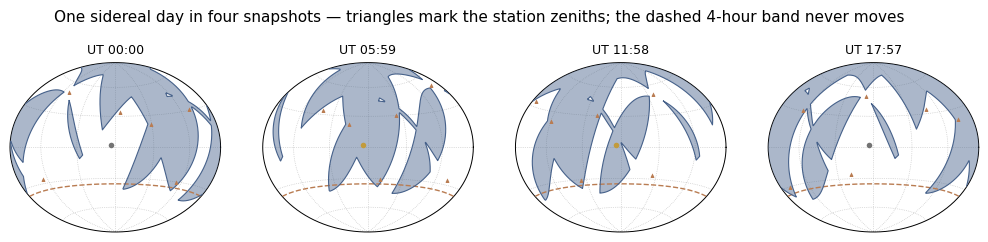

In [22]:
# fig-slug: covisibility-filmstrip
fig = plt.figure(figsize=(12.5, 2.2))
for k, i in enumerate([0, 9, 18, 27]):
    ax = sph.make_wcs_frame(141 + k, projection="AIT", center=180, fig=fig,
                            tick_style="native")
    band = sph.covisibility_duration_band(ax, ARRAY, min_hours=4.0,
                                          el_min=15, min_stations=3)
    band.render(facecolor="none", edgecolor=C[1], lw=1.0, linestyle="--")
    reg = sph.covisibility_region(ax, ARRAY, steps[i], el_min=15, min_stations=3)
    reg.render(facecolor=C[0], alpha=0.45, edgecolor=C[0], lw=0.8)
    caps = sph.covisibility_circles(ARRAY, steps[i], el_min=15)
    ax.scatter([c["center"].ra.deg for c in caps],
               [c["center"].dec.deg for c in caps], s=9, marker="^",
               color=C[1], lw=0, transform=ax.get_transform("world"), zorder=6)
    ax.plot([QSO[0]], [QSO[1]], "o", ms=4,
            color=C[2] if reg.contains_point(*QSO) else "0.45",
            mec="none", transform=ax.get_transform("world"), zorder=6)
    ax.set_title(f"UT {steps[i].iso[11:16]}", fontsize=9)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
fig.suptitle("One sidereal day in four snapshots — triangles mark the "
             "station zeniths; the dashed 4-hour band never moves",
             y=1.12, fontsize=11)
plt.show()

> **Note:** each animation frame recomputes the full spherical set-algebra
> intersection, so this is the priciest loop in the notebook — still nothing
> next to the encode time of the movie itself. If you need many more frames,
> compute the regions up front and swap pre-rendered artists instead.

## 8. Putting it together

The capstone stacks every layer this notebook has built: `make_globe_angles`
supplies the motion (§4), a per-frame `make_nightshade_blend` supplies the clock
(§5), a medium-gray graticule rides on top for reference, and a starfield
backdrop finishes the scene. The spin is synced against the
timestamps: the subsolar point drifts west at 15 degrees per hour — one full
turn over the 24 hours the timestamps span — so `spin_rate=360/n` matches it
exactly, and the camera stays parked a fixed angle from the Sun for the
whole day. The starting rotation (the `50` in the orientation triple) picks
*which* angle: a quarter-turn from the subsolar point, hovering over the
**dawn–dusk line**, where the terminator hangs still down the middle of the
frame while the planet turns underneath, each city sliding into its own
nightfall. And because the real Earth-orientation wobbles would be invisible
at this scale, the axis also carries an exaggerated nutation nod
(`nut_amp=6` — thousands of times the real amplitude), the same honest
exaggeration §4 used to make a nod visible at all:

In [23]:
n = 48
lons, lats, poles = sph.make_globe_angles([50, sph.obliquities["earth"], 10], n,
                                          spin_rate=360 / n,
                                          nut_rate=720 / n, nut_amp=6)
day_hours = [datetime(2026, 6, 20, 0, 0) + timedelta(hours=24 / n * i)
             for i in range(n)]
starfield = plt.imread(f"{DATA}/planet_maps/2k_stars.jpg")

# §5's `animate_blended_globe` bundles this into one call, but it drapes the maps
# *over* the graticule. Here we stack the same layers by hand — starfield, day,
# per-frame nightshade — draping at a low zorder so a medium-gray grid can ride on
# *top* of the night lights: a fixed reference that makes the axis nod legible.
fig = plt.figure(figsize=(5.2, 5.2))


def update(i):
    fig.clear()
    bg = fig.add_axes((0, 0, 1, 1))                          # starfield scenery behind the disk
    bg.set_zorder(-100)
    bg.imshow(starfield, aspect="auto")
    bg.axis("off")
    ax = sph.make_planet_frame(111, body="earth", center_LONdeg=lons[i],
                               center_LATdeg=lats[i], lonpole=poles[i], Naxispix=400,
                               tick_style="native", gridcolor="0.6", gridalpha=0.75)
    ax.set_facecolor("none")                                 # starfield shows past the disk
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    drape(ax, day_hdu)                                       # zorder -10, under the grid
    night_rgba = sph.make_nightshade_blend(night_hdu.data / 255.0, day_hours[i])
    drape(ax, fits.ImageHDU(night_rgba, night_hdu.header))
    ax.coords.grid(color="0.6", alpha=0.75, lw=0.7)          # graticule rides on top
    add_logo(fig, 0.035, 0.025, width=0.34, alpha=0.7)       # re-stamped each frame; alpha>default so the wireframe icon reads


# This one is opaque (starfield to the edges), so it stays lossy — but WebP like
# the rest, no mp4 special-case. Rendered smaller than the floating clips
# (~450 px): a full-frame globe carries its detail fine at that size, so bump=False.
ani = FuncAnimation(fig, update, frames=n, interval=100)
save_anim(ani, fig, "earth-day-and-night", fps=10, dpi=87, bg="#0E1117", bump=False)

animations__earth-day-and-night.webp: 0.54 MB


![A day of Earth: the globe turns eastward beneath a fixed dawn-dusk terminator while its axis carries an exaggerated nutation nod, city lights blooming across the night side, against a starfield.](../_static/animations/animations__earth-day-and-night.webp)

Five layers working together: Euler-angle sequences for the motion, per-frame
nightshade for the clock, a texture drape for the surface, a graticule for
reference, and a starfield behind the disk. Swap the angle recipe, the
timestamps, or the maps and the same loop renders a wobbling Mars, a time-lapse
eclipse track, or your own mission's ground illumination. The capstone filmstrip, with the
axis rod making the exaggerated nod visible:

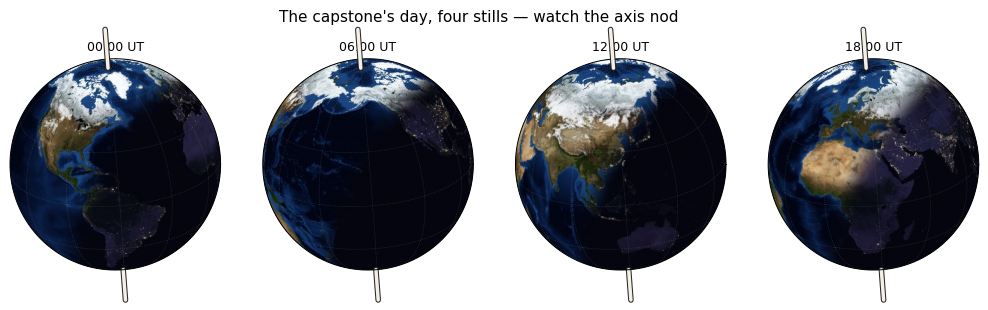

In [24]:
# fig-slug: capstone-filmstrip
fig = plt.figure(figsize=(12.5, 3.2))
for k, i in enumerate([0, 12, 24, 36]):
    ax = sph.make_planet_frame((1, 4, k + 1), body="earth",
                               center_LONdeg=lons[i], center_LATdeg=lats[i],
                               lonpole=poles[i], Naxispix=300,
                               tick_style="native",
                               gridcolor="0.6", gridalpha=0.3)
    for c in ax.coords:
        c.set_ticklabel_visible(False)
        c.set_ticks_visible(False)
    drape(ax, day_hdu)
    night_rgba = sph.make_nightshade_blend(night_hdu.data / 255.0, day_hours[i])
    drape(ax, fits.ImageHDU(night_rgba, night_hdu.header))
    sph.add_pole_rod(ax, length=1.4)
    ax.set_title(day_hours[i].strftime("%H:%M UT"), fontsize=9)
fig.suptitle("The capstone's day, four stills — watch the axis nod", fontsize=11)
plt.show()

## 9. Where to next

- **[Globe & Planet Plotting](globe_plots.ipynb)** — everything the globe
  frames can do standing still: Euler-angle geometry, textures, nightshade,
  Earth features, scale bars. The static half of §4–§5 and §8.
- **[Vector Fields & Sky Kinematics](vector_fields.ipynb)** — the
  proper-motion arrows §3 set in motion, and the co-visibility machinery §7
  animated, each in full depth.
- **[FITS Images & Quicklook](fits_images.ipynb)** — stretches, WCS handling,
  and cube tips behind §2's channel maps.
- **Interactive Plotting (plotly)** — when you want the *reader's hand* on
  the motion instead of a fixed loop: drag-rotate globes and slider-driven
  figures in the browser.
- The [globe guide page](../guide/globe.md) documents `make_globe_angles`,
  `animate_globe`, and `animate_blended_globe` parameters in reference form.

**Beyond matplotlib.** Everything here rides matplotlib's `FuncAnimation`,
which is the right tool when the frames *are* your plots. When the animation
is itself the explanation — a camera flying around a 3-D scene, labels that
morph, one projection dissolving into another — a purpose-built engine like
[manim](https://www.manim.community/) may be a better option. A natural pairing: let
manim run the 3-D camera and typography while skyplothelper renders the sky
frames it cuts to — e.g. a celestial sphere with a projection point and rays
striking a tangent plane, dissolving into the real `make_wcs_frame` map that
geometry produces. That's a separate toolchain (and a heavier install), so
it lives outside these notebooks — but it's where to look when a *fixed* loop
isn't enough.